Tyler Fields

CSCI 4650

Homework 6

In [ ]:
from math import sin, cos, pi, exp, sqrt
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate

---
## Exercise EX.5.1.2

We want to study the three-point centered-difference formula to approximate $ f'(x) $ where $ f(x) = e^x $ and $ x = 0 $.

Typed Questions:

---

(a) For this problem, what is f'(x)?

$$ f'(x) = e^x $$

---

(b) What is the three-point centered-difference formula in its general form?

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h}$$

---

(d) What is the three-point centered-difference approximation error in its general form? (Hint: There is a “c” in the formula. Specify an interval where c is.)

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} - \frac{h^2}{6}f'''(c)$$
where $ x-h < c < x+h$

---

(e) Find lower and upper bounds for the three-point centered-difference approximation error (independent of c). We call this an “interval where the approximation error is”. We want this interval to be “relevant”.

Since $ f(x) = e^x $, we know that $$ f'''(c) = e^c $$

We also know that $$ x-h < c < x+h $$

Therefore $$e^{x-h} < e^c < e^{x+h}$$

and so, $$e^{x-h} < f'''(c) < e^{x+h}$$

Finally, since the approximation error is $ \frac{h^2}{6}f'''(c) $, we get the following bounds
$$ -\frac{h^2}{6}e^{x+h} < (f'(x) - \frac{f(x+h) - f(x-h)}{2h}) < -\frac{h^2}{6}e^{x-h}$$

---

(g) In general, we are more interested in guaranteeing that “the error is not larger than”. We mean the absolute value of the error. (As opposed to find an interval where the error is.) Based on part (e), find an upper bound for the absolute value of the “true approximation error”. We call this an “upper
bound on the approximation error”.

In part (e), we found the interval $$ -\frac{h^2}{6}e^{x+h}, -\frac{h^2}{6}e^{x-h} $$

We can bound the absolute value of the approximation error by $ \frac{h^2}{6}e^{x+h} $ and get
$$\left| f'(x) - \frac{f(x+h) - f(x-h)}{2h} \right| \le \frac{h^2}{6}e^{x+h}$$

---

(f) Check that the “true approximation error” is within your interval of part (e)

Running the part (f) code cell shows

a. for $h = 0.1$, indeed, the approximation error ($-1.6675 \cdot 10^{-3}$) is in the interval $(-1.8420\cdot10^{-3},\ -1.5081\cdot10^{-3})$

b. for $h = 0.01$, indeed, the approximation error ($-1.6667 \cdot 10^{-5}$) is in the interval $(-1.6835\cdot10^{-5},\ -1.6501\cdot10^{-5})$

c. for $h = 0.001$, indeed, the approximation error ($-1.6667 \cdot 10^{-7}$) is in the interval $(-1.6684\cdot10^{-7},\ -1.6650\cdot10^{-7})$

---

(g) In general, we are more interested in guaranteeing that “the error is not larger than”. We mean the absolute value of the error. (As opposed to find an interval where the error is.) Based on part (e), find an upper bound for the absolute value of the “true approximation error”. We call this an “upper
bound on the approximation error”.

In part (e), we obtained the following interval:

$$\left(-\frac{h^2}{6}e^{x+h},\ -\frac{h^2}{6}e^{x-h}\right)$$

for the approximation error. Since $h > 0$, we know $e^{x+h} > e^{x-h} > 0$, and so both endpoints of this interval are negative, with

$$-\frac{h^2}{6}e^{x+h} < -\frac{h^2}{6}e^{x-h} < 0$$

The endpoint farther from zero (i.e. with the larger absolute value) is $-\frac{h^2}{6}e^{x+h}$. Therefore, we can bound the absolute value of the approximation error by $\frac{h^2}{6}e^{x+h}$. We get

$$\left| f'(x) - \frac{f(x+h) - f(x-h)}{2h} \right| \le \frac{h^2}{6}e^{x+h}$$

In [ ]:
# (c) Use the three-point centered-difference formula to approximate f ′(x) for (a) h = 0.1, (b)
#     h = 0.01, and (c) h = 0.001? Observe that, as h gets smaller, the approximation gets better. (However if
#     we were to take h too small, we would suffer from cancellation error and start losing accuracy.)

f  = lambda x : exp(x)
fp = lambda x : exp(x)

three_point_centered_difference_formula = lambda x, h : ( f(x+h) - f(x-h) ) / (2*h)

x = 0

print(f"{'h':>7} {'approx':>12}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    print(f"{h:7.0e} {approx:12.8f}")

      h       approx
  1e-01   1.00166750
  1e-02   1.00001667
  1e-03   1.00000017


In [ ]:
# -----------------
# (f) Check that the "true approximation error" is within your interval of part (e).
# -----------------

print(f"{'h':>7} {'approx':>12} {'error':>12} {'approximation error interval':>30}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    error  = fp(x) - approx
    lower  = -(h**2/6) * exp(x+h)
    upper  = -(h**2/6) * exp(x-h)
    print(f"{h:7.0e} {approx:12.8f} {error:12.4e} ({lower:9.3e}, {upper:9.3e})")

      h       approx        error   approximation error interval
  1e-01   1.00166750  -1.6675e-03 (-1.842e-03, -1.508e-03)
  1e-02   1.00001667  -1.6667e-05 (-1.683e-05, -1.650e-05)
  1e-03   1.00000017  -1.6667e-07 (-1.668e-07, -1.665e-07)


In [ ]:
# -----------------
# (h) Check that an "upper bound on the approximation error" is an upper bound on
#     the approximation error. We want this upper bound to be "relevant".
# -----------------

upper_bound_atx0 = lambda h : (h**2 / 6.) * exp(h)

print(f"{'h':>7} {'approx':>12} {'|error|':>12} {'upper bound':>14}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    error  = abs(fp(x) - approx)
    bound  = upper_bound_atx0(h)
    print(f"{h:7.0e} {approx:12.8f} {error:12.4e} {bound:14.4e}")

      h       approx      |error|    upper bound
  1e-01   1.00166750   1.6675e-03     1.8420e-03
  1e-02   1.00001667   1.6667e-05     1.6834e-05
  1e-03   1.00000017   1.6667e-07     1.6683e-07


---
## Exercise EX.5.1.4

We want to study the three-point centered-difference formula to approximate $f'(x)$ where $f(x) = sin x$ and $x = \frac{π}{3}$

Typed Questions:

---

(a) For this problem, what is $f'(x)$?

Since $f(x) = \sin x$,

$$f'(x) = \cos x$$

---

(b) What is the three-point centered-difference formula in its general form?

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h}$$

---

(d) What is the three-point centered-difference approximation error in its general form? (Hint: There is a "c" in the formula. Specify an interval where c is.)

$$f'(x) = \frac{f(x+h) - f(x-h)}{2h} - \frac{h^2}{6}f'''(c)$$
where $ x-h < c < x+h$

---

(e) Since we work with small positive $h$'s, let us assume that $h$ is in $(-0.2, 0.2)$, so that $x-h$ and $x+h$ are in $(0, \frac{\pi}{2})$, find lower and upper bounds for the three-point centered-difference approximation error (independent of $c$). We call this an "interval where the approximation error is". We want this interval to be "relevant".

Since $f = sin$, we know that

$$f'''(c) = -\cos(c)$$

Because $c$ is in $(x-h, x+h)$, $c$ is in $(0, \frac{\pi}{2})$, so that

$$0 \le \cos(c) \le 1$$

therefore,

$$-1 \le -\cos(c) \le 0$$

and

$$-1 \le f'''(c) \le 0$$

So that

$$0 \le -\frac{h^2}{6}f'''(c) \le \frac{h^2}{6}$$

And so an "interval where the approximation error is" is

$$0 \le \left(f'(x) - \frac{1}{2h}\big(f(x+h) - f(x-h)\big)\right) \le \frac{h^2}{6}$$

And so an "interval where the approximation error is" is

$$\left(0,\ \frac{h^2}{6}\right)$$

---

(f) Check that the "true approximation error" is within your interval of part (e)

Running the part (f) code cell shows

a. for $h = 0.1$, indeed, the approximation error ($8.329 \cdot 10^{-4}$) is in the interval $(0.000\cdot10^{0},\ 1.667\cdot10^{-3})$

b. for $h = 0.01$, indeed, the approximation error ($8.333 \cdot 10^{-6}$) is in the interval $(0.000\cdot10^{0},\ 1.667\cdot10^{-5})$

c. for $h = 0.001$, indeed, the approximation error ($8.333 \cdot 10^{-8}$) is in the interval $(0.000\cdot10^{0},\ 1.667\cdot10^{-7})$

---

(g) In general, we are more interested in guaranteeing that "the error is not larger than". We mean the absolute value of the error. (As opposed to find an interval where the error is.) Based on part (e), find an upper bound for the absolute value of the "true approximation error". We call this an "upper bound on the approximation error".

In part (e), we obtained the following interval:

$$\left(0,\ \frac{h^2}{6}\right)$$

for the approximation error. Since this interval is already entirely **non-negative**, with

$$0 \le \left(f'(x) - \frac{f(x+h)-f(x-h)}{2h}\right) \le \frac{h^2}{6}$$

the approximation error is automatically equal to its own absolute value here — there's no sign-flipping needed, unlike in a case where the interval is entirely negative. Therefore, we can bound the absolute value of the approximation error directly by the upper endpoint, $\frac{h^2}{6}$. We get

$$\left| f'(x) - \frac{f(x+h) - f(x-h)}{2h} \right| \le \frac{h^2}{6}$$

In [ ]:
# (c) Use the three-point centered-difference formula to approximate f ′(x) for (a) h = 0.1, (b)
#     h = 0.01, and (c) h = 0.001? Observe that, as h gets smaller, the approximation gets better. (However if
#     we were to take h too small, we would suffer from cancellation error and start losing accuracy.)

f  = lambda x : sin(x)
fp = lambda x : cos(x)

three_point_centered_difference_formula = lambda x, h : ( f(x+h) - f(x-h) ) / (2*h)

x = pi / 3

print(f"{'h':>7} {'approx':>12}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    print(f"{h:7.0e} {approx:12.8f}")

      h       approx
  1e-01   0.49916708
  1e-02   0.49999167
  1e-03   0.49999992


In [ ]:
# (f) Check that the "true approximation error" is within your interval of part (e).

print(f"{'h':>7} {'approx':>12} {'error':>12} {'approximation error interval':>30}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    error  = fp(x) - approx
    lower  = 0
    upper  = h**2 / 6
    print(f"{h:7.0e} {approx:12.8f} {error:12.4e} ({lower:9.3e}, {upper:9.3e})")

      h       approx        error   approximation error interval
  1e-01   0.49916708   8.3292e-04 (0.000e+00, 1.667e-03)
  1e-02   0.49999167   8.3333e-06 (0.000e+00, 1.667e-05)
  1e-03   0.49999992   8.3333e-08 (0.000e+00, 1.667e-07)


In [ ]:
# (h) Check that an "upper bound on the approximation error" is an upper bound on
#     the approximation error. We want this upper bound to be "relevant".

upper_bound = lambda h : h**2 / 6.

print(f"{'h':>7} {'approx':>12} {'|error|':>12} {'upper bound':>14}")
for h in [0.1, 0.01, 0.001]:
    approx = three_point_centered_difference_formula(x, h)
    error  = abs(fp(x) - approx)
    bound  = upper_bound(h)
    print(f"{h:7.0e} {approx:12.8f} {error:12.4e} {bound:14.4e}")

      h       approx      |error|    upper bound
  1e-01   0.49916708   8.3292e-04     1.6667e-03
  1e-02   0.49999167   8.3333e-06     1.6667e-05
  1e-03   0.49999992   8.3333e-08     1.6667e-07


---
## Exercise EX.5.1.8

Prove the second-order formula for the first derivative

$$f'(x) = \frac{-f(x+2h)+4f(x+h)-3f(x)}{2h} + O(h^2)$$

---

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(c_1)$$

$$f(x+2h) = f(x) + 2hf'(x) + \frac{(2h)^2}{2}f''(x) + \frac{(2h)^3}{6}f'''(c_2)$$

$$= f(x) + 2hf'(x) + 2h^2f''(x) + \frac{4}{3}h^3f'''(x) + O(c_2)$$

---

$$-f(x+2h) = -f(x) - 2hf'(x) - 2h^2f''(x) - \frac{4}{3}h^3f'''(c_2)$$

$$4f(x+h) = 4f(x) + 4hf'(x) + 2h^2f''(x) + \frac{2}{3}h^3f'''(c_1)$$

Adding these together along with $-3f(x)$ gives

$$-f(x+2h) + 4f(x+h) - 3f(x)$$

Remaining terms:

$$- \frac{4}{3}h^3f'''(c_2) + \frac{2}{3}h^3f'''(c_1)$$

---
So,

$$-f(x+2h)+4f(x+h)-3f(x) = 2hf'(x) + \frac{2}{3}h^3f'''(c_1) - \frac{4}{3}h^3f'''(c_2)$$

$$\frac{-f(x+2h)+4f(x+h)-3f(x)}{2h} = f'(x) + \frac{1}{3}h^2f'''(c_1)- \frac{2}{3}h^2f'''(c_2)$$

$$f'(x) = \frac{-f(x+2h)+4f(x+h)-3f(x)}{2h} + \frac{1}{3}h^2f'''(c_1) - \frac{2}{3}h^2f'''(c_2)$$

Since $\frac{1}{3}h^2f'''(x)$ is itself $O(h^2)$ and it dominates the smaller remainder, the combined error is $O(h^2)$:

$$f'(x) = \frac{-f(x+2h)+4f(x+h)-3f(x)}{2h} + O(h^2)$$


---
## Exercise EX.5.1.10

Find the error term and order for the approximation formula

$$f'(x) \approx \frac{4f(x+h)-3f(x)-f(x-2h)}{6h}$$

---

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f''''(c_1)$$

$$f(x-2h) = f(x) - 2hf'(x) + 2h^2f''(x) - \frac{4h^3}{3}f'''(x) + \frac{2h^4}{3}f''''(c_2)$$

$$4f(x+h) = 4f(x) + 4hf'(x) + 2h^2f''(x) + \frac{2h^3}{3}f'''(x) + \frac{h^4}{6}f''''(c_1)$$

$$-f(x-2h) = -f(x) + 2hf'(x) - 2h^2f''(x) + \frac{4h^3}{3}f'''(x) - \frac{2h^4}{3}f''''(c_2)$$

---

$$4f(x+h) - 3f(x) - f(x-2h) = 6hf'(x) + 2h^3f'''(x) + \frac{1}{6}h^4f''''(c_1) - \frac{2}{3}h^4f''''(c_2)$$

$$\frac{4f(x+h) - 3f(x) - f(x-2h)}{6h} = f'(x) + \frac{h^2}{3}f'''(x) + \frac{1}{36}h^3f''''(c_1) - \frac{1}{9}h^3f''''(c_2)$$

$$f'(x) = \frac{4f(x+h) - 3f(x) - f(x-2h)}{6h} - \frac{h^2}{3}f'''(x) + O(h^3)$$

---

$$\frac{4f(x+h) - 3f(x) - f(x-2h)}{6h} = f'(x) + \frac{h^2}{3}f'''(x) + O(h^3)$$

$$\text{Error} = \frac{h^2}{3}f'''(x) + O(h^3)$$

---
## Exercise EX.5.1.18

Find an upper bound for E(h) the error of the machine approximation of the two-point forward difference formula for the first derivative and then find the h corresponding to the minimum of E(h).

---
For some c between x and x + h:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(c)$$

$$f'(x) = \frac{f(x+h)-f(x)}{h} - \frac{h}{2}f''(c)$$

Truncation error:

$$\left|\frac{h}{2}f''(c)\right| \le \frac{h}{2}M, \qquad \text{where } M = \max_{c}|f''(c)|$$

Rounding error:

$$|\frac{e_2-e_1}{h}| \le \frac{2\varepsilon_{mach}}{h}$$

Total error bound:

$$E(h) = \frac{2\varepsilon_{mach}}{h} + \frac{h}{2}M$$

$$E'(h) = -\frac{2\varepsilon_{mach}}{h^2} + \frac{M}{2} = 0$$

$$h = 2\sqrt{\frac{\varepsilon_{mach}}{M}}$$

---
## Exercise EX.5.1.20

Prove the second-order formula for the third derivative

$$f'''(x) = \frac{f(x-3h) - 6f(x-2h) + 12f(x-h) - 10f(x) + 3f(x+h)}{2h^3} + O(h^2)$$

---

$$f(x+kh) = f(x) + khf'(x) + \frac{k^2h^2}{2}f''(x) + \frac{k^3h^3}{6}f'''(x) + \frac{k^4h^4}{24}f''''(x) + \frac{k^5h^5}{120}f^{(5)}(c_k)$$

$$f(x-3h) = f(x) -3hf'(x) + \frac{9h^2}{2}f''(x) - \frac{9h^3}{2}f'''(x) + \frac{27h^4}{8}f''''(x) - \frac{81h^5}{40}f^{(5)}(c_1)$$

$$f(x-2h) = f(x) -2hf'(x) + 2h^2f''(x) - \frac{4h^3}{3}f'''(x) + \frac{2h^4}{3}f''''(x) - \frac{4h^5}{15}f^{(5)}(c_2)$$

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f''''(x) - \frac{h^5}{120}f^{(5)}(c_3)$$

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f''''(x) + \frac{h^5}{120}f^{(5)}(c_4)$$

---

$$f(x-3h) - 6f(x-2h) + 12f(x-h) - 10f(x) + 3f(x+h) = 2h^3f'''(x) + h^5 R(h)$$

$$R(h) = -\frac{81}{40}f^{(5)}(c_1) + \frac{8}{5}f^{(5)}(c_2) - \frac{1}{10}f^{(5)}(c_3) + \frac{1}{40}f^{(5)}(c_4)$$

$$|R(h)| \le \left(\frac{81}{40} + \frac{8}{5} + \frac{1}{10} + \frac{1}{40}\right)M = \frac{15}{4}M$$

---

$$\frac{f(x-3h) - 6f(x-2h) + 12f(x-h) - 10f(x) + 3f(x+h)}{2h^3} = f'''(x) + \frac{h^2}{2}R(h)$$

$$f'''(x) = \frac{f(x-3h) - 6f(x-2h) + 12f(x-h) - 10f(x) + 3f(x+h)}{2h^3} + O(h^2)$$

  h     approx( x, h )   abs. error
1e-01  -0.250626566416    6.266e-04
1e-02  -0.250006250156    6.250e-06
1e-03  -0.250000062500    6.250e-08
1e-04  -0.250000000625    6.250e-10
1e-05  -0.250000000010    9.964e-12
1e-06  -0.250000000035    3.494e-11
1e-07  -0.249999999868    1.316e-10
1e-08  -0.249999998481    1.519e-09
1e-09  -0.250000020685    2.069e-08
1e-10  -0.250000020685    2.069e-08
1e-11  -0.250000020685    2.069e-08
1e-12  -0.250022225146    2.223e-05


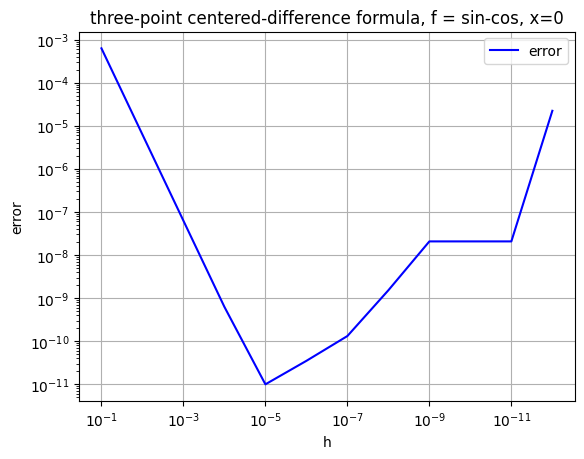

In [ ]:
# -----------------
# Exercise CP.5.1.2
# -----------------

# We want to study the three-point centered-difference formula to approximate
# f'(x) where f(x) = (x+1)^-1 and x = 1

# (a) Make a table and plot of the error of the three-point centered-difference
#     formula for f'(x), where f = (x + 1)^−1 and x = 1, with 10^−1,...,10^−12,
#     as in the table in Section 5.1.2. Draw a plot of the results.

f  = lambda x : (x + 1)**-1

three_point_centered_difference_formula = lambda x, h : ( f(x+h) - f(x-h) ) / 2. / h

x = 1.

fp = lambda x : -1. / (x + 1)**2
approximation_error = lambda x, h : \
  fp(x) - three_point_centered_difference_formula( x, h )

print(  "  h  ", "  approx( x, h )", "  abs. error" )

array_of_h = 10. ** ( - np.arange(1, 13, 1, dtype=float) )
array_of_error = np.zeros( np.size(array_of_h) )

for i in range(0,np.size(array_of_h)):

    h = array_of_h[i]
    array_of_error[i] = abs(approximation_error( x, h ))
    print(  f"{h:5.0e}",
          f"{three_point_centered_difference_formula( x, h ):16.12f}","  ",
          f"{array_of_error[i]:6.3e}")

plt.loglog( array_of_h, array_of_error, '-b', label='error' )
plt.xlabel('h')
plt.ylabel('error')
plt.title('three-point centered-difference formula, f = sin-cos, x=0')
plt.grid()
plt.legend()
plt.gca().invert_xaxis()

plt.show()

In [ ]:
# (b) Use the formula given below Equation (5.12) in the book to compute
#     an approximation to h_opt. In this formula M is |f ′′′(x)|, and ε_mach
#     is the machine precision that you can get in python with np.finfo(float).eps.

x = 1.

# M is f'''(x)
M = -6 / (x + 1)**4

# machine precision
machine_epsilon = np.finfo(float).eps

h_opt = (3*machine_epsilon/abs(M))**(1./3.)

print(  "minimum error should be around h =", f"{h_opt:6.1e}" )

minimum error should be around h = 1.2e-05


minimum error should be around h = 1.2e-05
  h     approx( x, h )    abs. error
1e-01  -0.250626566416    6.266e-04 6.250e-04
1e-02  -0.250006250156    6.250e-06 6.250e-06
1e-03  -0.250000062500    6.250e-08 6.250e-08
1e-04  -0.250000000625    6.250e-10 6.272e-10
1e-05  -0.250000000010    9.964e-12 2.845e-11
1e-06  -0.250000000035    3.494e-11 2.221e-10
1e-07  -0.249999999868    1.316e-10 2.220e-09
1e-08  -0.249999998481    1.519e-09 2.220e-08
1e-09  -0.250000020685    2.069e-08 2.220e-07
1e-10  -0.250000020685    2.069e-08 2.220e-06
1e-11  -0.250000020685    2.069e-08 2.220e-05
1e-12  -0.250022225146    2.223e-05 2.220e-04


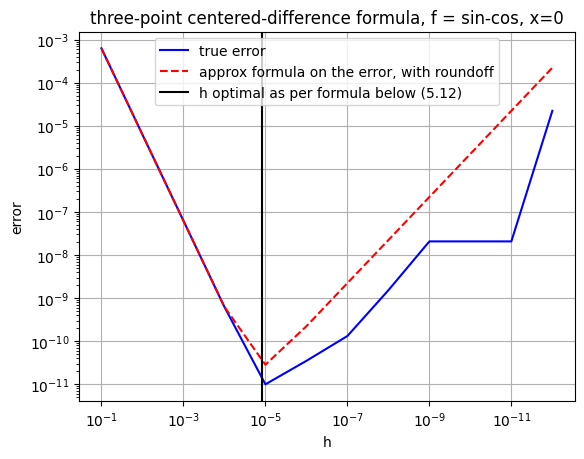

In [ ]:
# (c) Redo part (a) by adding E(h) from Equation (5.11) to your table and to your plot.
#     You can approximate the quantity f′′′(x) by M.

f  = lambda x : (x + 1)**-1

three_point_centered_difference_formula = lambda x, h : ( f(x+h) - f(x-h) ) / 2. / h

x = 1.

# remember that, in practical scenario, we will not know fp(x),
# since fp(x) is what we are trying to approximate,
# so, in practical scenario, we cannot compute `approximation_error`
# in this `toy` scenario, we know fp(x), so we can compute `approximation_error`
fp = lambda x : -1. / (x + 1)**2
approximation_error = lambda x, h : \
  fp(x) - three_point_centered_difference_formula( x, h )

# M is f'''(x)
M = -6 / (x + 1)**4

# machine precision
machine_epsilon = np.finfo(float).eps

h_opt = (3*machine_epsilon/abs(M))**(1./3.)

print(  "minimum error should be around h =", f"{h_opt:6.1e}" )


print(  "  h  ", "  approx( x, h )", "   abs. error" )

array_of_h = 10. ** ( - np.arange(1, 13, 1, dtype=float) )
array_of_error = np.zeros( np.size(array_of_h) )
formula__eq_5_11 = np.zeros( np.size(array_of_h) )

for i in range(0,np.size(array_of_h)):

    h = array_of_h[i]
    array_of_error[i] = abs(approximation_error( x, h ))
    formula__eq_5_11[i] = h**2 / 6. * abs( M ) + machine_epsilon / h
    print(  f"{h:5.0e}",
          f"{three_point_centered_difference_formula( x, h ):16.12f}","  ",
          f"{array_of_error[i]:6.3e}",
          f"{formula__eq_5_11[i]:6.3e}")

plt.loglog( array_of_h, array_of_error, '-b', label='true error' )
plt.loglog( array_of_h, formula__eq_5_11, '--r', label='approx formula on the error, with roundoff' )
plt.xlabel('h')
plt.ylabel('error')
plt.title('three-point centered-difference formula, f = sin-cos, x=0')
plt.axvline(x = h_opt, color = 'k', label='h optimal as per formula below (5.12)')
plt.grid()
plt.legend()
plt.gca().invert_xaxis()
plt.show()

---
## Exercise EX.5.2.4.b

Apply the composite Simpson's Rule with m = 1, 2 and 4 panels to the following integral. Compute the error by comparing with the exact value from calculus

$$\int_0^1 \frac{1}{1+x^2}\,dx$$

---

Integration by parts gives:

$$\int_0^1 \frac{1}{1+x^2}\,dx = \left[\arctan(x)\right]_0^1 = \arctan(1) - \arctan(0) = \frac{\pi}{4} - 0$$

$$\int_0^1 \frac{1}{1+x^2}\,dx = \frac{\pi}{4} \approx 0.7853981634$$

Applying the composite Simpson's Rule with m = 1, 2 and 4 panels to the following integral.

One panel, m = 1:

$$h=\frac{1}{2}:\quad x_0=0,\ x_1=\frac{1}{2},\ \text{and}\ x_2=1$$

$$\frac{h}{3}\left(y_0+4y_1+y_2\right)=\frac{h}{3}\left(f(x_0)+4f(x_1)+f(x_2)\right)$$

Using python helper code below we find: 0.7833333333333333

Two panels, m = 2:

$$h=\frac{1}{4}:\quad x_0=0,\ x_1=\frac{1}{4},\ x_2=\frac{1}{2},\ x_3=\frac{3}{4},\ \text{and}\ x_4=1,$$

$$\frac{h}{3}\left(y_0+4y_1+2y_2+4y_3+y_4\right)=\frac{h}{3}\left(f(x_0)+4f(x_1)+2f(x_2)+4f(x_3)+f(x_4)\right)$$

Using python helper code below we find: 0.7853921568627451

Four panels, m = 4:

$$h=\frac{1}{8}:\quad x_0=0,\ x_1=\frac{1}{8},\ x_2=\frac{1}{4},\ x_3=\frac{3}{8},\ x_4=\frac{1}{2},\ x_5=\frac{5}{8},\ x_6=\frac{3}{4},\ x_7=\frac{7}{8},\ \text{and}\ x_8=1,$$

$$\frac{h}{3}\left(y_0+4y_1+2y_2+4y_3+2y_4+4y_5+2y_6+4y_7+y_8\right)$$

$$\frac{h}{3}\left(f(x_0)+4f(x_1)+2f(x_2)+4f(x_3)+2f(x_4)+4f(x_5)+2f(x_6)+4f(x_7)+f(x_8)\right)$$

Using python helper code below we find: 0.7853981256146767

---

We see that as m increases, the approximations get closer to the true value $\frac{\pi}{4}$

Computing the error by comparing with the exact value from calculus:

$$h=\frac{1}{2}:\quad \text{true error} = |0.7833333333333333 - 0.7853981633974484| \approx 2.06\times10^{-3}$$

$$h=\frac{1}{4}:\quad \text{true error} = |0.7853921568627451 - 0.7853981633974484| \approx 6.01\times10^{-6}$$

$$h=\frac{1}{8}:\quad \text{true error} = |0.7853981256146767 - 0.7853981633974484| \approx 3.78\times10^{-8}$$

We see that as the number of panels, m, increases, the “true” error of the approximation composite Simpson's Rule goes to zero

In [ ]:
# -------------------------------
# Exercise EX.5.2.4.b Helper Code
# -------------------------------

f = lambda x : 1. / ( 1. + x ** 2 )
a = 0.
b = 1.

# method 0: calculus
# computing the exact value by hand, an antiderivative of 1/(1+x^2) is
# arctan(x), so we get
#     int _0 ^1 ( 1/(1+x^2) ) dx = arctan(1) - arctan(0) = pi/4

integral0 = pi / 4.

print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quad

integral1 = scipy.integrate.quad( f, a, b)[0]

print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.1e}")

# method 2:
# composite Simpson's Rule with m = 1, 2 and 4 panels

integral2 = (1/2)/3*( f(0) + 4*f(1/2) + f(1) )
integral3 = (1/4)/3*( f(0) + 4*f(1/4) + 2*f(1/2) + 4*f(3/4) + f(1) )
integral4 = (1/8)/3*( f(0) + 4*f(1/8) + 2*f(1/4) + 4*f(3/8)
    + 2*f(1/2) + 4*f(5/8) + 2*f(3/4) + 4*f(7/8) + f(1) )

h=1./2.; print("integral2 =", f"{integral2:20.16f}",
      "   error =", f"{abs(integral2-integral0):6.1e}")
h=1./4.; print("integral3 =", f"{integral3:20.16f}",
      "   error =", f"{abs(integral3-integral0):6.1e}")
h=1./8.; print("integral4 =", f"{integral4:20.16f}",
      "   error =", f"{abs(integral4-integral0):6.1e}")

integral0 =   0.7853981633974483
integral1 =   0.7853981633974484    error = 1.1e-16
integral2 =   0.7833333333333333    error = 2.1e-03
integral3 =   0.7853921568627451    error = 6.0e-06
integral4 =   0.7853981256146767    error = 3.8e-08


---
## Exercise EX.5.2.6.b

Apply the composite Simpson's Rule with m = 1, 2 and 4 panels to the following integral. Compute the error by comparing with the exact value from calculus

---

"Trusted" reference value using scripy: 1.3179021514544036

One panel, m = 1:

$$ h = 1:\quad w = \frac{1}{2} $$

$$ hf(w) $$

Using python helper code below we find: 1.2974425414002564

Two panels, m = 2:

$$ h = \frac{1}{2}:\quad w_1 = \frac{1}{4}, w_2 = \frac{3}{4} $$

$$ hf(w_1) + hf(w_2) $$

Using python helper code below we find: 1.3127175111172660

Four panels, m = 4:

$$ h = \frac{1}{4}:\quad w_1 = \frac{1}{8}, w_2 = \frac{3}{8}, w_3 = \frac{5}{8}, w_4 = \frac{7}{8} $$

$$ hf(w_1) + hf(w_2) + hf(w_3) + hf(w_4) $$

Using python helper code below we find: 1.3166015542711800

We see that as the number of panels, m, increases, the approximations composite Midpoint Rule approximate the integral better and better. We get closer and closer to the trusted value of 1.3179021514544036.

In [ ]:
# -------------------------------
# Exercise EX.5.2.6.b Helper Code
# -------------------------------

# f(0) is undefined so we use midpoint a midpoint rule

f = lambda x : np.where( np.abs(x) < 1e-12, 1., ( np.exp(x) - 1 ) / np.where(x==0, 1., x) )
a = 0.
b = 1.

# method 0: calculus
# There is no elementary antiderivative for (e^x - 1)/x, so we need numerical
# methods to get an approximation.

# method 1:
# using scipy.integrate.quad

integral1 = scipy.integrate.quad( f, a, b)[0]

print("Method 1:")
print("integral1 =", f"{integral1:20.16f}")

# method 2:
# composite Midpoint Rule with m = 1, 2 and 4 panels

integral2 = 1*f(1/2)
integral3 = 1/2*( f(1/4) + f(3/4) )
integral4 = 1/4*( f(1/8) + f(3/8)+ f(5/8) + f(7/8) )


print("\nMethod 2:")
h=1.; print("integral2 =", f"{integral2:20.16f}",
      "   error =", f"{abs(integral2-integral1):6.1e}" )
h=1./2.; print("integral3 =", f"{integral3:20.16f}",
      "   error =", f"{abs(integral3-integral1):6.1e}" )
h=1./4.; print("integral4 =", f"{integral4:20.16f}",
      "   error =", f"{abs(integral4-integral1):6.1e}" )

# method 3:
# we use composite Simpson's Rule with m = 1, 2 and 4 panels
# but we extend f by continuity with f(0) = 1

f0 = 1.
integral2 = (1/2)/3*( f0 + 4*f(1/2) + f(1) )
integral3 = (1/4)/3*( f0 + 4*f(1/4) + 2*f(1/2) + 4*f(3/4) + f(1) )
integral4 = (1/8)/3*( f0 + 4*f(1/8) + 2*f(1/4) + 4*f(3/8)
    + 2*f(1/2) + 4*f(5/8) + 2*f(3/4) + 4*f(7/8) + f(1) )


print("\nMethod 3:")
print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral1):6.2e}")
print("integral3 =", f"{integral3:20.16f}", "   error =", f"{abs(integral3-integral1):6.2e}")
print("integral4 =", f"{integral4:20.16f}", "   error =", f"{abs(integral4-integral1):6.2e}")

Method 1:
integral1 =   1.3179021514544036

Method 2:
integral2 =   1.2974425414002564    error = 2.0e-02
integral3 =   1.3127175111172660    error = 5.2e-03
integral4 =   1.3166015542711800    error = 1.3e-03

Method 3:
integral2 =   1.3180086656766783    error = 1.07e-04
integral3 =   1.3179089166831404    error = 6.77e-06
integral4 =   1.3179025760028127    error = 4.25e-07


In [ ]:
# -------------------
# Exercise CP.5.2.1.a
# -------------------

# Use the composite Trapezoid Rule with m = 16 and 32 panels to approximate the
# definite integral. Compare with the correct integral and report the two errors

def composite_trapezoid( f, a, b, m ):
    h = ( b - a ) / m
    integral = 0
    x = a
    for i in range(1,m,1):
        x = x + h
        integral = integral + f( x )
    integral = 2 * integral
    integral = integral + ( f( a ) + f( b ) )
    integral = ( h / 2 ) * integral
    return integral


f = lambda x : x / sqrt( ( x ** 2 ) + 9 )
a = 0
b = 4

# method 0:
# an antiderivative for `x / sqrt(x^2 + 9)` is  `sqrt(x^2 + 9)`
# so we find that
#     int _0 ^4 ( x / sqrt(x^2 + 9) ) dx = sqrt(4^2+9) - sqrt(0^2+9) = sqrt(25) - sqrt(9) = 5 - 3 = 2

integral0 = sqrt( b**2 + 9 ) - sqrt( a**2 + 9 )
print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quadrature

integral1 = scipy.integrate.quad( f, a, b)[0]
print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.2e}")

# method 2:
# using composite Trapezoid Rule with m = 16

integral2 = composite_trapezoid( f, a, b, 16 )
print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral0):6.2e}")

# method 3:
# using composite Trapezoid Rule with m = 32

integral3 = composite_trapezoid( f, a, b, 32 )
print("integral3 =", f"{integral3:20.16f}", "   error =", f"{abs(integral3-integral0):6.2e}")


integral0 =   2.0000000000000000
integral1 =   2.0000000000000000    error = 0.00e+00
integral2 =   1.9986381814702789    error = 1.36e-03
integral3 =   1.9996596780779112    error = 3.40e-04


In [ ]:
# -------------------
# Exercise CP.5.2.2.a
# -------------------

# Use the composite Simpson’s Rule with m = 16 and 32 panels to approximate the
# definite integral. Compare with the correct integral and report the two errors.

def composite_simpson( f, a, b, m ):
    h = ( b - a ) / 2 / m
    x = a
    sum = 0
    for i in range(1,m,1):
        x = x + 2 * h
        sum = sum + f( x )
    integral = 2. * sum
    x = a + h
    sum = 0
    for i in range(1,m,1):
        x = x + 2 * h
        sum = sum + f( x )
    integral = integral + 4. * sum
    integral = integral + ( f( a ) + f( b ) )
    integral = ( h / 3 ) * integral
    return integral

f = lambda x : x / sqrt( ( x ** 2 ) + 9 )
a = 0
b = 4

# method 0:
# an antiderivative for `x / sqrt(x^2 + 9)` is  `sqrt(x^2 + 9)`
# so we find that
#     int _0 ^4 ( x / sqrt(x^2 + 9) ) dx = sqrt(4^2+9) - sqrt(0^2+9) = sqrt(25) - sqrt(9) = 5 - 3 = 2

integral0 = sqrt( b**2 + 9 ) - sqrt( a**2 + 9 )
print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quad

integral1 = scipy.integrate.quad( f, a, b)[0]
print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.2e}")

# method 2:
# using composite Simpson's Rule with m = 16

integral2 = composite_simpson( f, a, b, 16 )
print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral0):6.2e}")

# method 3:
# using composite Simpson's Rule with m = 32

integral3 = composite_simpson( f, a, b, 32 )
print("integral3 =", f"{integral3:20.16f}", "   error =", f"{abs(integral3-integral0):6.2e}")

integral0 =   2.0000000000000000
integral1 =   2.0000000000000000    error = 0.00e+00
integral2 =   1.9930617528284253    error = 6.94e-03
integral3 =   1.9982642765640277    error = 1.74e-03


---
## Exercise EX.5.3.2.b

Apply Romberg Integration to find R33 for the following integral

$$\int_0^1 \frac{1}{1+x^2}\,dx$$

---

We recall from EX.5.2.4.b that the exact value of the integral is $\frac {\pi}{4}$

The final answer of the itegration process is $R_{33}$, we get

$$ 0.7855294117647058 $$

The values obtained are:

$R11 =   0.7500000000000000$

$R21 =   0.7750000000000000\quad     R22 =   0.7833333333333333$

$R31 =   0.7827941176470588\quad    R32 =   0.7853921568627450\quad    R33 =   0.7855294117647058$

Associated errors are:

$3.54e-02$

$1.04e-02\quad   2.06e-03$

$2.60e-03\quad   6.01e-06\quad   1.31e-04$

Computing $R_{33}$ only required 5 function evaluations.

As computed in EX.5.2.4.b, we note that $R_{22}$ is exactly Simpson with m = 1 and $R_{32}$ is exactly Simpson with m = 2.

In [ ]:
# -------------------------------
# Exercise EX.5.3.2.b Helper Code
# -------------------------------

f = lambda x : 1 / ( 1 + x**2 )
a = 0.
b = 1.

integral0 = pi / 4.
print("integral0 =", f"{integral0:20.16f}\n")

h1 = 1; h2 = 1/2; h3 = 1/4

R11 = 1/2 * h1 * ( f(0) + f(1) )
R21 = 1/2 * R11 + h2 * f( 1/2 )
R31 = 1/2 * R21 + h3 * ( f( 1/4 ) + f( 3/4 ) )

R22 = ( 4 * R21 - R11 ) / 3
R32 = ( 4 * R31 - R21 ) / 3
R33 = ( 16 * R32 - R22 ) / 15

print("R11 =", f"{R11:20.16f}")
print("R21 =", f"{R21:20.16f}", "   R22 =", f"{R22:20.16f}")
print("R31 =", f"{R31:20.16f}", "   R32 =", f"{R32:20.16f}", "   R33 =", f"{R33:20.16f}")

print()
print("errors:")
print(f"{abs(R11-integral0):6.2e}")
print(f"{abs(R21-integral0):6.2e}   {abs(R22-integral0):6.2e}")
print(f"{abs(R31-integral0):6.2e}   {abs(R32-integral0):6.2e}   {abs(R33-integral0):6.2e}")

integral0 =   0.7853981633974483

R11 =   0.7500000000000000
R21 =   0.7750000000000000    R22 =   0.7833333333333333
R31 =   0.7827941176470588    R32 =   0.7853921568627450    R33 =   0.7855294117647058

errors:
3.54e-02
1.04e-02   2.06e-03
2.60e-03   6.01e-06   1.31e-04


In [ ]:
# -------------------
# Exercise CP.5.3.1.a
# -------------------

# Use Romberg Integration approximation R_55 to approximate the definite integral
# below. Compare with the correct integral, and report the error.

def romberg( f, a, b, n ):
  r = np.zeros([n,n])
  h = ( b - a ) / 2 ** ( np.arange(0,n) )
  r[0,0] = ( b - a ) * ( f(a) + f(b) ) / 2.
  for j in range(1,n):
    subtotal = 0
    for i in range(0,2**(j-1)):
      subtotal = subtotal + f ( a + ( 2*i+1 ) * h[j] )
    r[j,0] = r[j-1,0] / 2. + h[j] * subtotal
    for k in range(1,j+1):
      r[j,k] = ( 4**k * r[j,k-1] - r[j-1,k-1] ) / ( 4**k - 1 )
  return r

f = lambda x : x / sqrt( ( x ** 2 ) + 9 )
a = 0
b = 4

# method 0:
# an antiderivative for `x / sqrt(x^2 + 9)` is  `sqrt(x^2 + 9)`
# so we find that
#     int _0 ^4 ( x / sqrt(x^2 + 9) ) dx = sqrt(4^2+9) - sqrt(0^2+9) = sqrt(25) - sqrt(9) = 5 - 3 = 2

integral0 = sqrt( b**2 + 9 ) - sqrt( a**2 + 9 )
print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quad

integral1 = scipy.integrate.quad( f, a, b)[0]
print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.2e}")

# method 2:
# using Romberg Integration approximation R_{55}
n = 5
integral2 = romberg( f, a, b, n )[n-1,n-1]
print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral0):6.2e}\n")

# print the whole Romberg table, and associated errors
n = 5
np.set_printoptions(precision=10)
print(romberg( f, a, b, n ))
print()
np.set_printoptions(precision=0)
print(abs(romberg( f, a, b, n )-np.tril(np.ones(n))*integral0))

integral0 =   2.0000000000000000
integral1 =   2.0000000000000000    error = 0.00e+00
integral2 =   2.0000001041237434    error = 1.04e-07

[[1.6          0.           0.           0.           0.          ]
 [1.9094003925 2.0125338566 0.           0.           0.          ]
 [1.9780347434 2.0009128604 2.0001381273 0.           0.          ]
 [1.9945441641 2.0000473044 1.9999896006 1.9999872431 0.          ]
 [1.9986381815 2.0000028539 1.9999998906 2.0000000539 2.0000001041]]

[[4.e-01 0.e+00 0.e+00 0.e+00 0.e+00]
 [9.e-02 1.e-02 0.e+00 0.e+00 0.e+00]
 [2.e-02 9.e-04 1.e-04 0.e+00 0.e+00]
 [5.e-03 5.e-05 1.e-05 1.e-05 0.e+00]
 [1.e-03 3.e-06 1.e-07 5.e-08 1.e-07]]


In [ ]:
# -------------------
# Exercise CP.5.4.1.a
# -------------------

# Use Adaptive Trapezoid Quadrature to approximate the definite integral within
# 0.5 · 10−8. Report the number of subintervals used

def trapezoid( f, a, b ):
    return ( ( b - a ) / 2. ) * ( f(a) + f(b) )

f = lambda x : x / sqrt( ( x ** 2 ) + 9 )
a = 0
b = 4

# method 0:
# an antiderivative for `x / sqrt(x^2 + 9)` is  `sqrt(x^2 + 9)`
# so we find that
#     int _0 ^4 ( x / sqrt(x^2 + 9) ) dx = sqrt(4^2+9) - sqrt(0^2+9) = sqrt(25) - sqrt(9) = 5 - 3 = 2

integral0 = sqrt( b**2 + 9 ) - sqrt( a**2 + 9 )
print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quad

integral1 = scipy.integrate.quad( f, a, b)[0]
print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.2e}")

# method 2:
# using Adaptive Trapezoid Quadrature

tol = 0.5e-8

count = 0

def Adaptive_Trapezoid_Quadrature( f, a, b, tol ):

    global count

    c = ( b + a ) / 2.

    if ( abs( trapezoid( f, a, b ) - trapezoid( f, a, c ) - trapezoid( f, c, b ) ) < 3. * tol ):

        count = count + 2

        return trapezoid( f, a, c ) + trapezoid( f, c, b )

    else:

        return Adaptive_Trapezoid_Quadrature( f, a, c, tol / 2. ) + Adaptive_Trapezoid_Quadrature( f, c, b, tol / 2. )

integral2 = Adaptive_Trapezoid_Quadrature( f, a, b, tol )

print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral0):6.2e}")
print("\nnumber of subintervals used =", count)

integral0 =   2.0000000000000000
integral1 =   2.0000000000000000    error = 0.00e+00
integral2 =   1.9999999974992955    error = 2.50e-09

number of subintervals used = 12606


In [ ]:
# -------------------
# Exercise EX.5.5.6.d
# -------------------

# Approximate the integral using n = 4 Gaussian Quadrature.
# int _{-3} ^ 3 ( exp( - x^2 / 2 ) ) dx

# method 0:
# computing the exact value by hand, so there is no antiderivative for exp(-x^2).
# but computing the integral of exp(-x^2) is so important
# (because this is needed to integrate a Gaussian,
# and the integral of a Gaussian is very very important in Statistics )
# there is a function just for this: ``erf``. The error function.


# erf is 2/sqrt(pi)*integral(exp(-t**2), t=0..z).

#      int _{-3} ^ 3 ( exp( - x^2 / 2 ) ) dx
# change of variable sqrt(2) * x = t
#  =   1 / sqrt(2) * int _{-3/sqrt(2)} ^ {3/sqrt{2}} ( exp( - t^2 ) ) dt
#  =   2 / sqrt(2) * int _{0} ^ {3/sqrt{2}} ( exp( - t^2 ) ) dt
#  =   sqrt( 2 * pi ) * erf( 3 / sqrt(2) )

integral0 = sqrt( 2. * pi ) * scipy.special.erf( 3. / sqrt(2.) )

print("integral0 =", f"{integral0:20.16f}")

# method 1:
# using scipy.integrate.quad

f = lambda x : np.exp( - x ** 2 / 2.)
a = -3.
b = 3.

integral1 = scipy.integrate.quad( f, a, b)[0]
print("integral1 =", f"{integral1:20.16f}", "   error =", f"{abs(integral1-integral0):6.2e}")

# method 2:
# using Gaussian quadrature with 4 panels.

x0 = - sqrt( ( 15. + 2. * sqrt( 30. ) ) / 35. )
x1 = - sqrt( ( 15. - 2. * sqrt( 30. ) ) / 35. )
x2 = + sqrt( ( 15. - 2. * sqrt( 30. ) ) / 35. )
x3 = + sqrt( ( 15. + 2. * sqrt( 30. ) ) / 35. )

w0 = ( 90. - 5. * sqrt(30.) ) / 180.
w1 = ( 90. + 5. * sqrt(30.) ) / 180.
w2 = ( 90. + 5. * sqrt(30.) ) / 180.
w3 = ( 90. - 5. * sqrt(30.) ) / 180.


# ( a + b ) / 2. + ( b - a ) / 2. * x0...x3
x0 = 3. * x0
x1 = 3. * x1
x2 = 3. * x2
x3 = 3. * x3

integral2 = ( b - a ) / 2. * ( w0 * f(x0) + w1 * f(x1) + w2 * f(x2) + w3 * f(x3) )

print("integral2 =", f"{integral2:20.16f}", "   error =", f"{abs(integral2-integral0):6.2e}")

# method 3:
# using scipy.special.roots_legendre for computing the integration nodes and the weights

x, w = scipy.special.roots_legendre(4)

integral3 = 0.5 * (b - a) * sum(w * f(0.5 * (b - a) * x + 0.5 * (b + a)))

print("integral3 =", f"{integral3:20.16f}", "   error =", f"{abs(integral3-integral0):6.2e}")

integral0 =   2.4998608894830947
integral1 =   2.4998608894830947    error = 0.00e+00
integral2 =   2.4001355303532481    error = 9.97e-02
integral3 =   2.4001355303532481    error = 9.97e-02
